# 🤖 Baseline vs Thompson Sampling
## Treino, comparação e registro de experimentos (MLflow)

**Objetivo deste notebook:** treinar e comparar duas estratégias de decisão
para "devo ofertar o produto a este cliente?":

1. **Baseline** — regra fixa (política de controle): sempre oferece o
   produto a todo mundo. É a régua de comparação — mede o que a instituição
   já faria hoje sem nenhuma inteligência adaptativa.
2. **Thompson Sampling contextual** — Multi-Armed Bandit bayesiano que
   segmenta clientes por contexto (idade + profissão, ~48 segmentos
   identificados na EDA como tendo comportamento distinto) e mantém uma
   posterior Beta(alpha, beta) própria por segmento. A cada decisão, ele
   amostra dessa posterior — equilibrando **exploração** (testar segmentos
   com pouca informação) e **explotação** (concentrar contato nos segmentos
   já conhecidos como bons).

Toda a lógica de treino vive em `src/recommender.py` (os modelos) e
`src/train.py` (o pipeline + registro no MLflow) — este notebook **reusa**
essas funções em vez de duplicar a lógica, para nunca ficar dessincronizado
do código que roda a API em produção (`src/app/`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from scipy import stats

from src.recommender import OfferRecommender, ThompsonSampler, evaluate_recommender
from src.train import load_or_prepare_data, train_baseline, run_thompson_experiment, PRIOR_CONFIGS, MLFLOW_DB_PATH, MLFLOW_ARTIFACT_DIR, EXPERIMENT_NAME

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')  # rodar a partir da raiz do repo (paths relativos: data/, models/, mlflow/)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Módulos importados com sucesso!")

✅ Módulos importados com sucesso!


## 1️⃣ Carregar Dados Preparados

Usamos `data/processed/train_clean.csv` e `data/processed/test_clean.csv`, já limpos, codificados
e normalizados por `src/data_preparation.py` (sem a coluna `duration`, que a
EDA identificou como vazamento temporal). Se esses arquivos ainda não
existirem, `load_or_prepare_data()` roda o pipeline de preparação
automaticamente a partir do CSV bruto.

In [2]:
X_train, y_train, X_test, y_test = load_or_prepare_data()

print(f"📊 Dados carregados:")
print(f"   Treino: {X_train.shape}")
print(f"   Teste:  {X_test.shape}")
print(f"\n   Taxa de 'Yes' no treino: {y_train.mean()*100:.1f}%")
print(f"   Taxa de 'Yes' no teste:  {y_test.mean()*100:.1f}%")

📥 Carregando dados...
   ✅ 41,188 registros carregados
🗑️ Removendo vazamento temporal...
   ✅ Coluna 'duration' removida
🧹 Limpando dados...
   ✅ Nenhum valor faltante
🔤 Codificando variáveis categóricas...
   Encontradas 10 colunas categóricas
   ✅ job: 12 classes codificadas
   ✅ marital: 4 classes codificadas
   ✅ education: 8 classes codificadas
   ✅ default: 3 classes codificadas
   ✅ housing: 3 classes codificadas
   ✅ loan: 3 classes codificadas
   ✅ contact: 2 classes codificadas
   ✅ month: 10 classes codificadas
   ✅ day_of_week: 5 classes codificadas
   ✅ poutcome: 3 classes codificadas


   ✅ Target 'y' convertido para binário (0/1)

📊 Separando em treino/teste (70/30)...


   Treino: 28,831 registros (11.3% Yes)
   Teste:  12,357 registros (11.3% Yes)

📈 Normalizando features...
   ✅ Features normalizadas com StandardScaler
   Treino shape: (28831, 19)
   Teste shape:  (12357, 19)

💾 Salvando datasets em data/processed...


   ✅ data/processed/train_clean.csv (28,831 x 20)


   ✅ data/processed/test_clean.csv (12,357 x 20)
   ✅ data/processed/scaler.pkl
   ✅ data/processed/encoders.json
   ✅ data/processed/feature_names.json (19 features)

✅ PREPARAÇÃO CONCLUÍDA

Metadados:
  n_features: 19
  n_train: 28831
  n_test: 12357
  train_yes_rate: 0.11265651555617218
  test_yes_rate: 0.11264870114105366
  feature_names: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
📊 Dados carregados:
   Treino: (28831, 19)
   Teste:  (12357, 19)

   Taxa de 'Yes' no treino: 11.3%
   Taxa de 'Yes' no teste:  11.3%


**Nota:** a proporção de aceitação (~11%) é praticamente idêntica em
treino e teste — confirma que o split estratificado (`src/data_preparation.py`)
preservou o desbalanceamento observado na EDA em ambos os conjuntos.

## 2️⃣ Treinar BASELINE

O Baseline implementa a política de controle mais simples possível: sempre
recomenda ofertar (`recommend()` retorna 1 para todo cliente). Sua "confiança"
é constante — a taxa de aceitação histórica observada no treino — porque ele
não diferencia clientes. É a referência que qualquer estratégia adaptativa
precisa superar para se justificar.

In [3]:
baseline, baseline_metrics = train_baseline(X_train, y_train, X_test, y_test)


📊 Avaliação: BASELINE
  Accuracy:                    11.3%
  Precision:                   11.3%
  Recall:                      100.0%
  Taxa de aceitação esperada:  11.3%
  Taxa de aceitação real:      11.3%
  Clientes recomendados:       12,357 (100.0%)


## 3️⃣ Treinar THOMPSON SAMPLING contextual + MLflow

Testamos 3 configurações de prior para a posterior Beta de cada segmento —
do mais uninformativo ao mais fortemente ancorado na taxa de aceitação
histórica (~11%):

| Prior | alpha0 | beta0 | Interpretação |
|---|---|---|---|
| `uninformative` | 1.0 | 1.0 | Nenhum conhecimento prévio — Beta(1,1) é uniforme em [0,1] |
| `weakly-informative` | 2.0 | 16.0 | Média ≈ 11%, mas com baixa confiança — poucas "observações virtuais" |
| `strong-informative` | 5.0 | 40.0 | Média ≈ 11%, com mais confiança — precisa de mais dados reais para o segmento se afastar dessa média |

Cada configuração roda como um **run separado no MLflow** (experimento
`datathon-offers`), registrando parâmetros, métricas de avaliação no teste e
o modelo treinado como artefato — dá para comparar as 3 execuções lado a
lado depois com `mlflow ui`.

In [4]:
mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB_PATH}')
if mlflow.get_experiment_by_name(EXPERIMENT_NAME) is None:
    mlflow.create_experiment(EXPERIMENT_NAME, artifact_location=f'file:{MLFLOW_ARTIFACT_DIR}')
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name='baseline'):
    mlflow.log_param('strategy', 'baseline')
    mlflow.log_metrics(baseline_metrics)

thompson_runs = {}
for cfg in PRIOR_CONFIGS:
    model, metrics = run_thompson_experiment(
        cfg['alpha0'], cfg['beta0'], X_train, y_train, X_test, y_test, name=cfg['name']
    )
    with mlflow.start_run(run_name=f"thompson-{cfg['name']}"):
        mlflow.log_params({
            'strategy': 'thompson',
            'alpha0': cfg['alpha0'],
            'beta0': cfg['beta0'],
            'segment_columns': ','.join(ThompsonSampler.SEGMENT_COLUMNS),
        })
        mlflow.log_metrics(metrics)
        mlflow.log_metric('baseline_actual_acceptance', baseline_metrics['actual_acceptance'])

        tmp_path = f"models/_tmp_thompson_{cfg['name']}.json"
        model.save_json(tmp_path)
        mlflow.log_artifact(tmp_path, artifact_path='model')
        os.remove(tmp_path)
    thompson_runs[cfg['name']] = (model, metrics)

# Escolhe o melhor prior pela taxa de aceitação real no teste
best_name = max(thompson_runs, key=lambda k: thompson_runs[k][1]['actual_acceptance'])
thompson, thompson_metrics = thompson_runs[best_name]
print(f"\n🏆 Melhor prior: {best_name} (alpha0={thompson.model.alpha0}, beta0={thompson.model.beta0})")
print(f"   Segmentos de comportamento aprendidos: {len(thompson.model.segments)}")

2026/08/15 03:45:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/15 03:45:17 INFO mlflow.store.db.utils: Updating database tables



📊 Avaliação: THOMPSON uninformative (alpha0=1.0, beta0=1.0)


  Accuracy:                    62.3%
  Precision:                   15.6%
  Recall:                      53.2%
  Taxa de aceitação esperada:  11.3%
  Taxa de aceitação real:      15.6%
  Clientes recomendados:       4,750 (38.4%)



📊 Avaliação: THOMPSON weakly-informative (alpha0=2.0, beta0=16.0)


  Accuracy:                    63.0%
  Precision:                   15.7%
  Recall:                      52.2%
  Taxa de aceitação esperada:  11.2%
  Taxa de aceitação real:      15.7%
  Clientes recomendados:       4,629 (37.5%)



📊 Avaliação: THOMPSON strong-informative (alpha0=5.0, beta0=40.0)


  Accuracy:                    63.0%
  Precision:                   15.7%
  Recall:                      52.1%
  Taxa de aceitação esperada:  11.2%
  Taxa de aceitação real:      15.7%
  Clientes recomendados:       4,631 (37.5%)

🏆 Melhor prior: weakly-informative (alpha0=2.0, beta0=16.0)
   Segmentos de comportamento aprendidos: 48


**Interpretação:** os 3 priors convergem para resultados próximos no
teste porque cada segmento acumula centenas de observações no treino — o
suficiente para que os dados reais dominem qualquer prior razoável. A
diferença entre priors importaria mais com poucos dados por segmento (por
exemplo, logo após o lançamento do sistema em produção, antes de acumular
histórico).

## 4️⃣ Comparação de Desempenho

In [5]:
comparison = pd.DataFrame({
    'BASELINE': baseline_metrics,
    'THOMPSON': thompson_metrics
})

print("\n📊 COMPARAÇÃO DE DESEMPENHO")
print("="*70)
print(comparison.to_string())
print("="*70)

melhoria_pct = (thompson_metrics['actual_acceptance'] - baseline_metrics['actual_acceptance']) / baseline_metrics['actual_acceptance'] * 100 if baseline_metrics['actual_acceptance'] > 0 else 0
print(f"\n🎯 MELHORIA: Thompson é {melhoria_pct:.1f}% melhor que Baseline (taxa de aceitação real)")


📊 COMPARAÇÃO DE DESEMPENHO
                         BASELINE     THOMPSON
accuracy                 0.112649     0.630250
precision                0.112649     0.156837
recall                   1.000000     0.521552
expected_acceptance      0.112657     0.112123
actual_acceptance        0.112649     0.156837
n_recommended        12357.000000  4629.000000
n_segments                    NaN    48.000000

🎯 MELHORIA: Thompson é 39.2% melhor que Baseline (taxa de aceitação real)


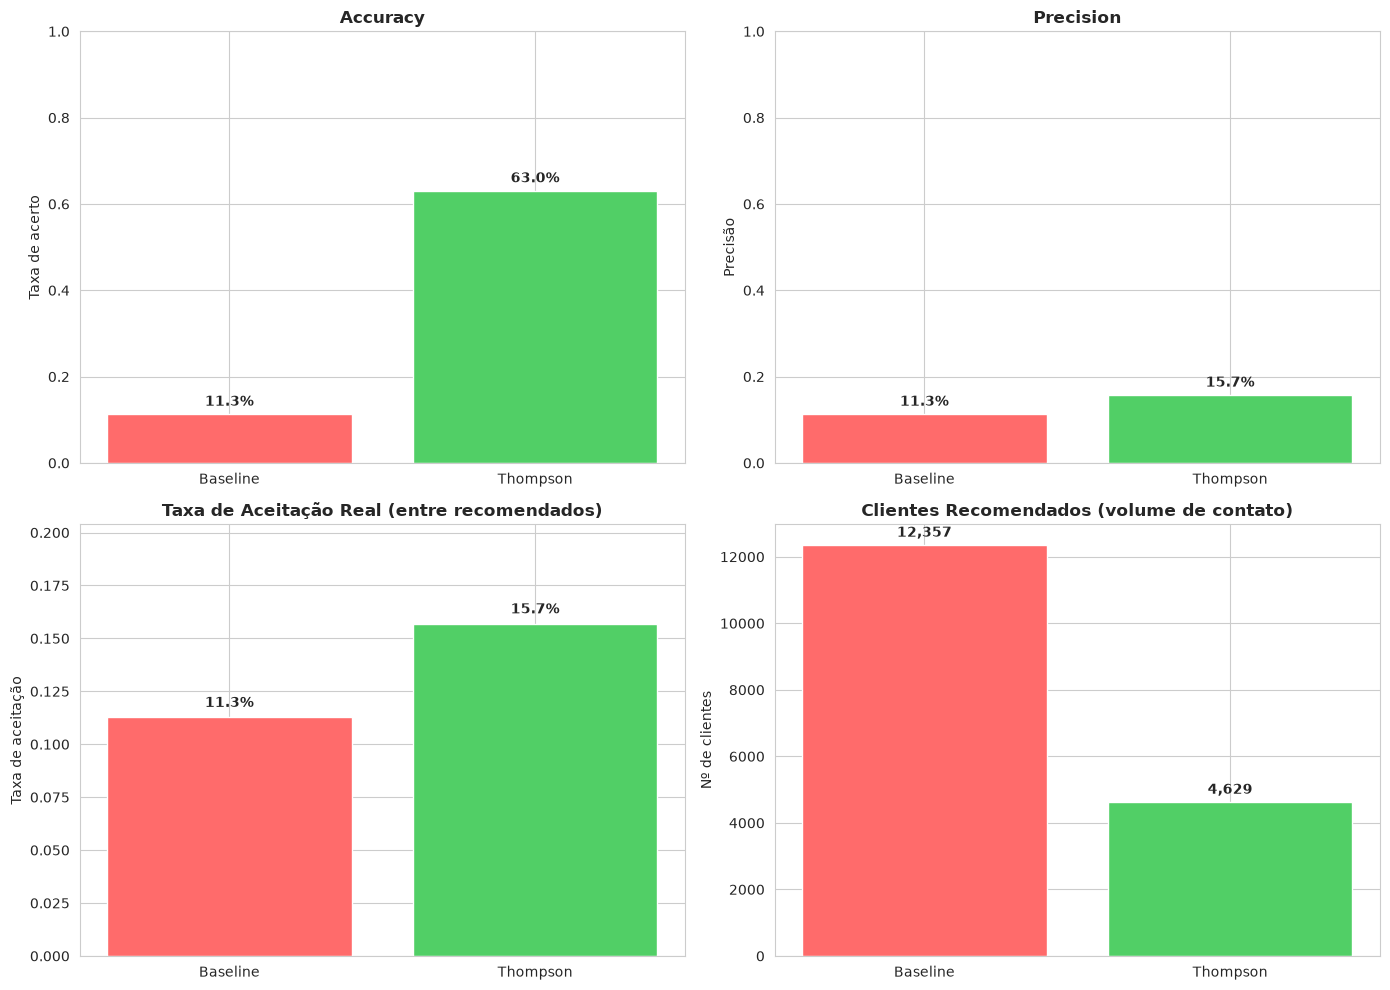

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

strategies = ['Baseline', 'Thompson']

accuracies = [baseline_metrics['accuracy'], thompson_metrics['accuracy']]
axes[0, 0].bar(strategies, accuracies, color=['#ff6b6b', '#51cf66'])
axes[0, 0].set_title('Accuracy', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Taxa de acerto')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')

precisions = [baseline_metrics['precision'], thompson_metrics['precision']]
axes[0, 1].bar(strategies, precisions, color=['#ff6b6b', '#51cf66'])
axes[0, 1].set_title('Precision', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Precisão')
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(precisions):
    axes[0, 1].text(i, v + 0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')

acceptances = [baseline_metrics['actual_acceptance'], thompson_metrics['actual_acceptance']]
axes[1, 0].bar(strategies, acceptances, color=['#ff6b6b', '#51cf66'])
axes[1, 0].set_title('Taxa de Aceitação Real (entre recomendados)', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Taxa de aceitação')
axes[1, 0].set_ylim([0, max(acceptances) * 1.3])
for i, v in enumerate(acceptances):
    axes[1, 0].text(i, v + 0.005, f'{v*100:.1f}%', ha='center', fontweight='bold')

recommended = [baseline_metrics['n_recommended'], thompson_metrics['n_recommended']]
axes[1, 1].bar(strategies, recommended, color=['#ff6b6b', '#51cf66'])
axes[1, 1].set_title('Clientes Recomendados (volume de contato)', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Nº de clientes')
for i, v in enumerate(recommended):
    axes[1, 1].text(i, v + max(recommended)*0.02, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Leitura dos 4 gráficos:** o Baseline sempre ofertar tem recall perfeito
(100% — nunca deixa de tentar ninguém que aceitaria) mas baixa accuracy e
baixa taxa de aceitação real, porque desperdiça contato em quem não vai
aceitar. O Thompson troca volume por precisão: oferece a bem menos clientes
(último gráfico), mas com uma taxa de aceitação real mais alta entre eles —
o resultado prático é usar o orçamento de contato de forma mais eficiente,
concentrando-o nos segmentos de maior propensão aprendida.

## 5️⃣ Análise de Exploração vs Explotação

Como o Thompson é segmentado por contexto, olhamos a convergência da
posterior do segmento mais populoso do treino: conforme mais observações
chegam, o intervalo de credibilidade (5%–95%) em torno da taxa de aceitação
estimada encolhe — a fase inicial de alta incerteza é a exploração, e a
estabilização é a explotação.

📈 Segmento mais populoso: 1|-1.038 (2133 clientes no treino)


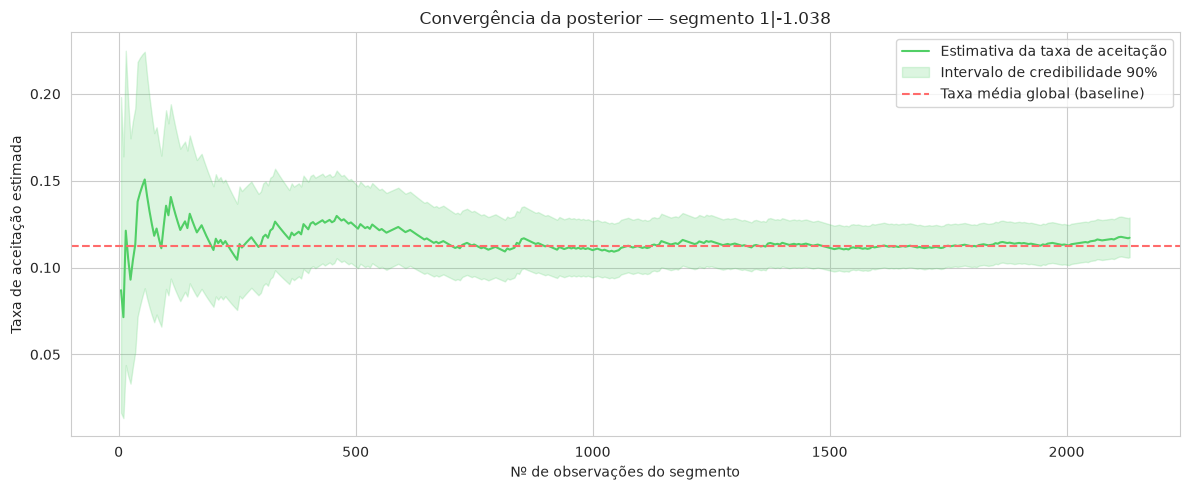

In [7]:
seg_keys = np.array([
    thompson.model._segment_key(a, j)
    for a, j in zip(X_train['age'].to_numpy(), X_train['job'].to_numpy())
])
top_segment = pd.Series(seg_keys).value_counts().idxmax()
mask = seg_keys == top_segment
y_seg = y_train[mask].reset_index(drop=True)

print(f"📈 Segmento mais populoso: {top_segment} ({mask.sum()} clientes no treino)")

alpha0, beta0 = thompson.model.alpha0, thompson.model.beta0
alpha, beta = alpha0, beta0
history = []
for t, r in enumerate(y_seg, start=1):
    if int(r) == 1:
        alpha += 1
    else:
        beta += 1
    if t % 5 == 0 or t == len(y_seg):
        mean = alpha / (alpha + beta)
        lo, hi = stats.beta.ppf([0.05, 0.95], alpha, beta)
        history.append({'t': t, 'mean': mean, 'lo': lo, 'hi': hi})

hist_df = pd.DataFrame(history)

plt.figure(figsize=(12, 5))
plt.plot(hist_df['t'], hist_df['mean'], color='#51cf66', label='Estimativa da taxa de aceitação')
plt.fill_between(hist_df['t'], hist_df['lo'], hist_df['hi'], color='#51cf66', alpha=0.2, label='Intervalo de credibilidade 90%')
plt.axhline(baseline_metrics['expected_acceptance'], color='#ff6b6b', linestyle='--', label='Taxa média global (baseline)')
plt.xlabel('Nº de observações do segmento')
plt.ylabel('Taxa de aceitação estimada')
plt.title(f'Convergência da posterior — segmento {top_segment}')
plt.legend()
plt.tight_layout()
plt.show()

**Leitura do gráfico:** no início (poucas observações), a faixa sombreada
(intervalo de credibilidade) é larga — o modelo ainda não tem certeza sobre
esse segmento, então explora (a amostragem da Beta varia bastante e pode
recomendar ofertar mesmo com estimativa baixa). Conforme mais respostas reais
chegam, a faixa estreita ao redor de um valor estável — o modelo passa a
explotar essa estimativa com confiança. Esse é o mecanismo central do
Thompson Sampling: a própria incerteza da posterior regula automaticamente
quanto explorar, sem precisar de um cronograma fixo de exploração (como em
epsilon-greedy).

## 6️⃣ Salvando Modelos

In [8]:
os.makedirs('models', exist_ok=True)
baseline.save_json('models/baseline.json')
thompson.save_json('models/thompson.json')

print("\n✅ Modelos salvos com sucesso!")
print("   - models/baseline.json")
print("   - models/thompson.json")


✅ Modelos salvos com sucesso!
   - models/baseline.json
   - models/thompson.json


Os modelos são salvos em **JSON** (não pickle) — evita risco de execução
de código arbitrário ao carregar um modelo salvo, e mantém o arquivo legível
(dá pra abrir e ver os segmentos e seus alpha/beta diretamente). São esses
arquivos que a API (`src/app/`) carrega para servir recomendações, e que o
notebook `03_evaluation.ipynb` usa para montar o Golden Set.

## 📋 CONCLUSÕES

In [9]:
print("\n" + "="*70)
print("🎯 CONCLUSÕES DO EXPERIMENTO")
print("="*70)

print(f"\n1️⃣ BASELINE (Regra Fixa):")
print(f"   Taxa de aceitação: {baseline_metrics['actual_acceptance']*100:.1f}%")
print(f"   Clientes abordados: {baseline_metrics['n_recommended']:,}")

print(f"\n2️⃣ THOMPSON SAMPLING CONTEXTUAL (prior={best_name}):")
print(f"   Taxa de aceitação: {thompson_metrics['actual_acceptance']*100:.1f}%")
print(f"   Clientes abordados: {thompson_metrics['n_recommended']:,}")
print(f"   Segmentos de comportamento aprendidos: {len(thompson.model.segments)}")

print(f"\n3️⃣ MELHORIA:")
if baseline_metrics['actual_acceptance'] > 0:
    melhoria = (thompson_metrics['actual_acceptance'] - baseline_metrics['actual_acceptance']) / baseline_metrics['actual_acceptance']
    print(f"   Thompson é {melhoria*100:.1f}% melhor que Baseline")
    print(f"   Ganho absoluto: {(thompson_metrics['actual_acceptance'] - baseline_metrics['actual_acceptance'])*100:.1f} pontos percentuais")

print(f"\n4️⃣ CONTEXTO NA DECISÃO:")
print(f"   Ao contrário de um bandit global (2 braços fixos para toda a base),")
print(f"   este Thompson Sampling mantém uma posterior por segmento de cliente,")
print(f"   então a confiança reportada pela API varia conforme idade e profissão.")

print("\n" + "="*70)
print("Execute 'mlflow ui --backend-store-uri sqlite:///mlflow/mlflow.db' para ver os runs registrados.")


🎯 CONCLUSÕES DO EXPERIMENTO

1️⃣ BASELINE (Regra Fixa):
   Taxa de aceitação: 11.3%
   Clientes abordados: 12,357

2️⃣ THOMPSON SAMPLING CONTEXTUAL (prior=weakly-informative):
   Taxa de aceitação: 15.7%
   Clientes abordados: 4,629
   Segmentos de comportamento aprendidos: 48

3️⃣ MELHORIA:
   Thompson é 39.2% melhor que Baseline
   Ganho absoluto: 4.4 pontos percentuais

4️⃣ CONTEXTO NA DECISÃO:
   Ao contrário de um bandit global (2 braços fixos para toda a base),
   este Thompson Sampling mantém uma posterior por segmento de cliente,
   então a confiança reportada pela API varia conforme idade e profissão.

Execute 'mlflow ui --backend-store-uri sqlite:///mlflow/mlflow.db' para ver os runs registrados.


---
**Próximo passo:** `03_evaluation.ipynb` carrega `models/baseline.json` e
`models/thompson.json` para montar o Golden Set (casos de teste manuais) e
aprofundar a análise de erros.